# Introduction

The EuroSAT dataset is a satellite image dataset used for land-use and land-cover classification tasks. It contains 27,000 RGB images categorized into 10 different classes, including AnnualCrop, Forest, Highway, Industrial, Pasture, Residential, River, SeaLake, PermanentCrop, and HerbaceousVegetation.

The objective of this Exploratory Data Analysis (EDA) is to understand the dataset structure, analyze class distribution, inspect sample images, verify image properties, and assess data quality before applying deep learning models for image classification.


Extracting and preparing the EuroSAT dataset for analysis

In [13]:
!unzip -q /content/archive.zip -d /content/dataset

replace /content/dataset/2750/AnnualCrop/AnnualCrop_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Display the contents of the extracted dataset directory

In [14]:
import os

print(os.listdir('/content/dataset'))

['2750']


Explore the directory structure and locate the dataset files

In [15]:
import os

for root, dirs, files in os.walk('/content'):
    print(root)
    if len(dirs) > 0:
        print("Folders:", dirs[:10])
    print("-"*50)

/content
Folders: ['.config', 'dataset', 'sample_data']
--------------------------------------------------
/content/.config
Folders: ['configurations', 'logs']
--------------------------------------------------
/content/.config/configurations
--------------------------------------------------
/content/.config/logs
Folders: ['2026.06.04']
--------------------------------------------------
/content/.config/logs/2026.06.04
--------------------------------------------------
/content/dataset
Folders: ['2750']
--------------------------------------------------
/content/dataset/2750
Folders: ['PermanentCrop', 'Industrial', 'River', 'Highway', 'HerbaceousVegetation', 'Forest', 'Pasture', 'SeaLake', 'AnnualCrop', 'Residential']
--------------------------------------------------
/content/dataset/2750/PermanentCrop
--------------------------------------------------
/content/dataset/2750/Industrial
--------------------------------------------------
/content/dataset/2750/River
---------------------

Dataset Path: /content/dataset/2750

Number of Classes: 10

Classes:
- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake

Analyze the class distribution by counting images in each category

In [16]:
import os
import pandas as pd

dataset_path = "/content/dataset/2750"

classes = []
counts = []

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)

    if os.path.isdir(cls_path):
        classes.append(cls)
        counts.append(len(os.listdir(cls_path)))

df = pd.DataFrame({
    "Class": classes,
    "Images": counts
})

print(df.sort_values("Class"))

                  Class  Images
8            AnnualCrop    3000
5                Forest    3000
4  HerbaceousVegetation    3000
3               Highway    2500
1            Industrial    2500
6               Pasture    2000
0         PermanentCrop    2500
9           Residential    3000
2                 River    2500
7               SeaLake    3000


Display sample images from each class for visual inspection

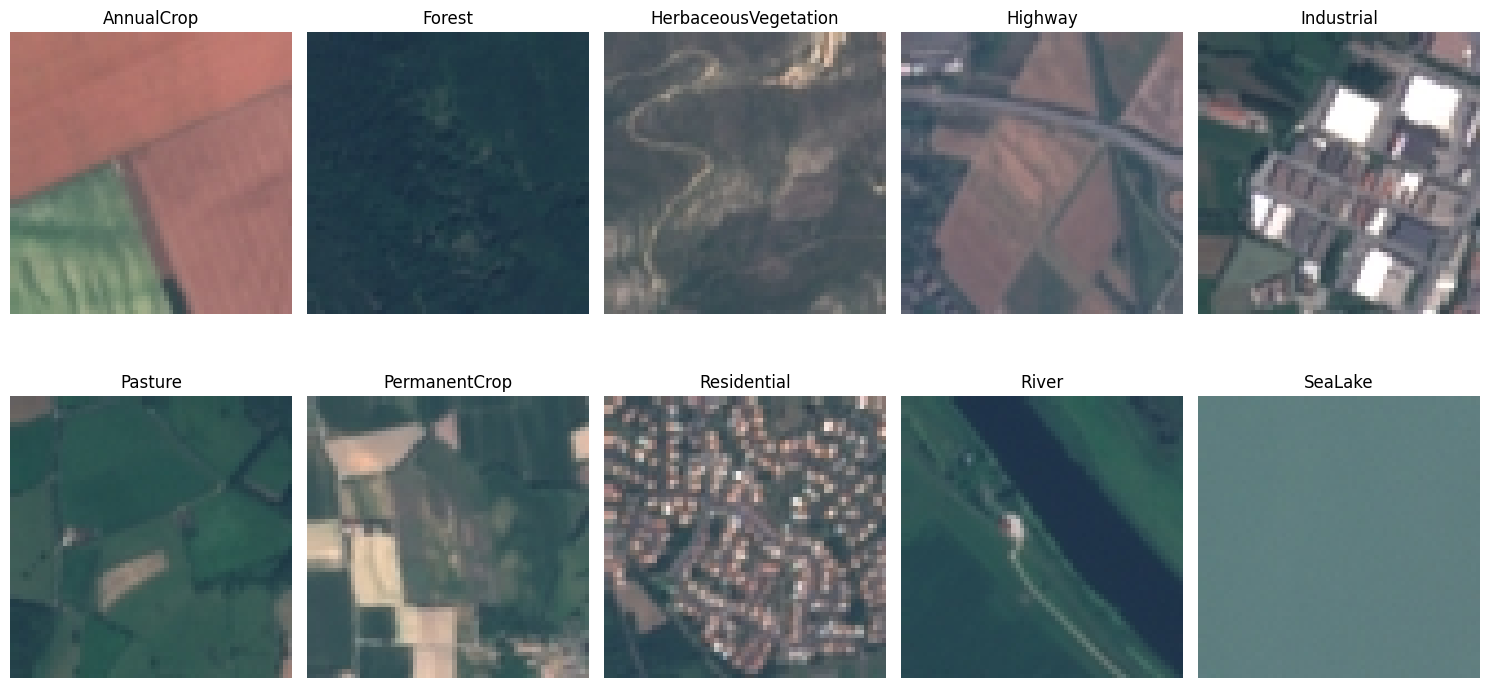

In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import os

dataset_path = "/content/dataset/2750"

classes = sorted(os.listdir(dataset_path))

plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(dataset_path, cls))[0]

    img_path = os.path.join(dataset_path, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

Sizes

In [18]:
from PIL import Image
import os

dataset_path = "/content/dataset/2750"

sizes = set()

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)

    img_name = os.listdir(cls_path)[0]

    img = Image.open(os.path.join(cls_path, img_name))

    sizes.add(img.size)

print("Unique Sizes:", sizes)

Unique Sizes: {(64, 64)}


Check the color mode of images in the dataset

In [19]:
from PIL import Image
import os

dataset_path = "/content/dataset/2750"

modes = set()

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)

    img_name = os.listdir(cls_path)[0]

    img = Image.open(os.path.join(cls_path, img_name))

    modes.add(img.mode)

print(modes)

{'RGB'}


Check the dataset for corrupted or unreadable images

In [20]:
from PIL import Image
import os

dataset_path = "/content/dataset/2750"

corrupted = 0

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(cls_path):
        try:
            img_path = os.path.join(cls_path, img_name)
            Image.open(img_path).verify()
        except:
            corrupted += 1

print("Corrupted Images:", corrupted)

Corrupted Images: 0


Visualize the distribution of images across all classes using a bar chart

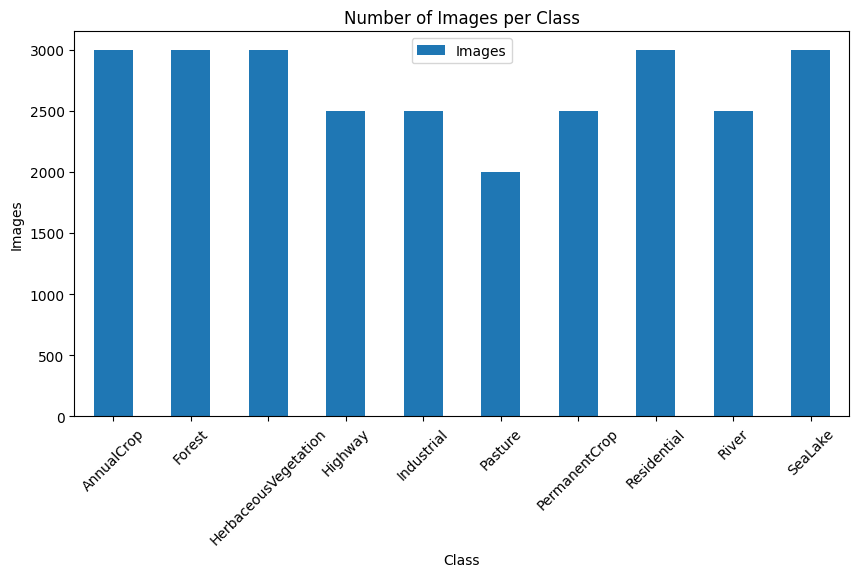

In [21]:
import matplotlib.pyplot as plt

df.sort_values("Class").plot(
    x="Class",
    y="Images",
    kind="bar",
    figsize=(10,5)
)

plt.title("Number of Images per Class")
plt.ylabel("Images")
plt.xticks(rotation=45)
plt.show()

 Visualize the proportion of images in each class using a pie chart

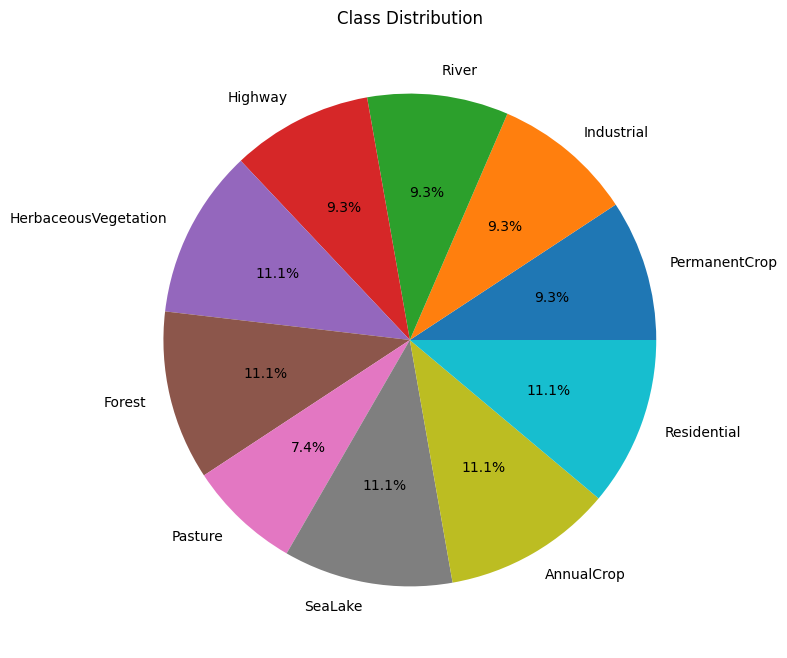

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.pie(
    df['Images'],
    labels=df['Class'],
    autopct='%1.1f%%'
)
plt.title('Class Distribution')
plt.show()

describe

In [23]:
print(df.describe())

            Images
count    10.000000
mean   2700.000000
std     349.602949
min    2000.000000
25%    2500.000000
50%    2750.000000
75%    3000.000000
max    3000.000000


Final Insights
Dataset contains 27,000 satellite images.
Images are distributed across 10 classes.
The dataset is relatively balanced.
All images have a resolution of 64×64 pixels.
All images are RGB.
No corrupted images were found.
Visual inspection shows clear differences between classes.